# Supplementary Figure S2: Scaling with Size and Squeezing

Supplementary Figure S2 compares how the boundary entropy and fitted central charge vary with graph size and squeezing in the undecorated and decorated constructions.

This figure includes:

* (a) undecorated entropy curves for several boundary sizes at fixed squeezing
* (b) undecorated entropy curves for several squeezing values at fixed $R_b$
* (c) undecorated fitted central charge versus squeezing
* (d) decorated entropy curves for several boundary sizes at fixed squeezing
* (e) decorated entropy curves for several squeezing values at fixed $R_b$
* (f) decorated fitted central charge versus squeezing

## Import Dependencies

In [3]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "global_figure_settings.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from __future__ import annotations

import loadconfig as loco
import matplotlib.pyplot as plt
import figure_helpers.scaling as scaling
import matplotlib.gridspec as gridspec

import numpy as np

from graph2grav.figure_hashing import save_figure_with_hash


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Make Figure

Assemble the six-panel scaling comparison and save the supplementary figure.

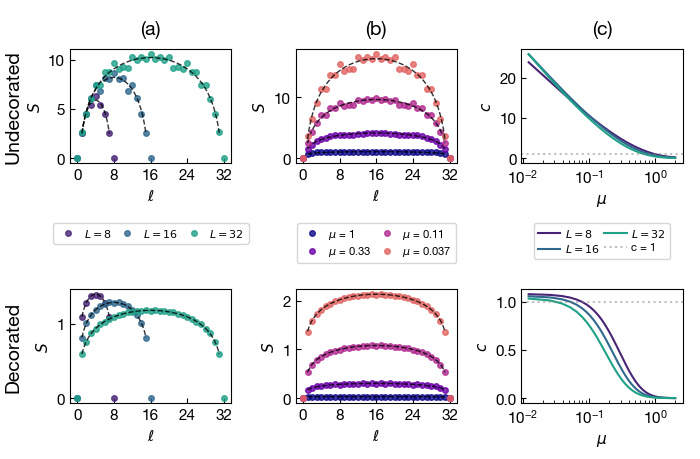

In [4]:
from matplotlib.transforms import Bbox

# (x0, y0, width, height) in INCHES of the figure
# bbox = Bbox.from_bounds(0.0, 0, 7.0, 5)

bottom_cut = 0.4
top_cut = 0
bbox = Bbox.from_bounds(0.0, bottom_cut, 7.0, 5.0 - bottom_cut - top_cut)

%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
%matplotlib inline


config = loco.reload()

# 1. Standard Setup
fig = plt.figure(figsize=(bbox.width, bbox.height + bottom_cut + top_cut)) # No layout engine needed

# 2. MASTER GRID (The 3 Columns)
# This controls the global margins and the gap BETWEEN the columns.
outer_gs = gridspec.GridSpec(2, 3, figure=fig, 
                             left=0.1, right=0.975, 
                             top=0.9, bottom=0.1, 
                             wspace=0.4, # Gap between the major columns
                             hspace=0.5, # Gap between rows
                             width_ratios=[1, 1, 1]) 

# 3. NESTED GRIDS (The Internals)

# --- Top Row: Undecorated ---
gs_left = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer_gs[0, 0],
    height_ratios=[1, 0.4], hspace=0)
ax_left = fig.add_subplot(gs_left[0])

gs_middle = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer_gs[0, 1],
    height_ratios=[1, 0.4], hspace=0)
ax_middle = fig.add_subplot(gs_middle[0])

gs_right = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer_gs[0, 2],
    height_ratios=[1, 0.4], hspace=0)
ax_right = fig.add_subplot(gs_right[0])

# --- Bottom Row: Decorated ---
gs_lower_left = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer_gs[1, 0],
    height_ratios=[1, 0.4], hspace=0)
ax_lower_left = fig.add_subplot(gs_lower_left[0])

gs_lower_middle = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer_gs[1, 1],
    height_ratios=[1, 0.4], hspace=0)
ax_lower_middle = fig.add_subplot(gs_lower_middle[0])

gs_lower_right = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer_gs[1, 2],
    height_ratios=[1, 0.4], hspace=0)
ax_lower_right = fig.add_subplot(gs_lower_right[0])


depths = [3, 4, 5]
squeezing_values = [1, 1/3, 1/9, 1/27]
squeezing_values_for_central_charge = np.linspace(1/81, 2, 150)


# --- Top Row: Undecorated ---
scaling.plot_entanglement_entropy_scaling_with_depth(ax_left, squeezing=1/10, depths=depths, config=config, is_decorated=False)
scaling.plot_entanglement_entropy_scaling_with_squeezing(ax_middle, squeezing_values=squeezing_values, config=config, is_decorated=False)
scaling.plot_central_charge_versus_squeezing(ax_right, squeezing_values=squeezing_values_for_central_charge, depths=depths, config=config, is_decorated=False)

# --- Bottom Row: Decorated ---
scaling.plot_entanglement_entropy_scaling_with_depth(ax_lower_left, squeezing=1/10, depths=depths, config=config, is_decorated=True)
scaling.plot_entanglement_entropy_scaling_with_squeezing(ax_lower_middle, squeezing_values=squeezing_values, config=config, is_decorated=True)
scaling.plot_central_charge_versus_squeezing(ax_lower_right, squeezing_values=squeezing_values_for_central_charge, depths=depths, config=config, is_decorated=True)

# --- Labels ---
ax_left.text(
    0.5, 1.1, "(a)",
    transform=ax_left.transAxes,
    ha="center", va="bottom",
    fontweight="bold",
    fontsize=14
)

ax_middle.text(
    0.5, 1.1, "(b)",
    transform=ax_middle.transAxes,
    ha="center", va="bottom",
    fontweight="bold",
    fontsize=14
)

ax_right.text(
    0.5, 1.1, "(c)",
    transform=ax_right.transAxes,
    ha="center", va="bottom",
    fontweight="bold",
    fontsize=14
)

# Write the word "Undecorated" and rotate it 90 degrees
ax_left.text(
    -0.35, 0.5, "Undecorated",
    transform=ax_left.transAxes,
    ha="center", va="center",
    fontweight="bold",
    fontsize=14,
    rotation=90
)

# Write the word "decorated" and rotate it 90 degrees
ax_lower_left.text(
    -0.35, 0.5, "Decorated",
    transform=ax_lower_left.transAxes,
    ha="center", va="center",
    fontweight="bold",
    fontsize=14,
    rotation=90
)

# --- Row titles ---
# ax_left.set_title("Undecorated", fontsize=10, fontweight="bold")
# ax_lower_left.set_title("Decorated", fontsize=10, fontweight="bold")

# --- Legends ---
ax_left.legend(fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.5),
              columnspacing=0.4,
    handletextpad=0.4,
    borderaxespad=0.2,
    labelspacing=0.3 
               )
ax_middle.legend(fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.5),
              columnspacing=0.4,
    handletextpad=0.4,
    borderaxespad=0.2,
    labelspacing=0.3
                 )
ax_right.legend(fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.5),
              columnspacing=0.4,
    handletextpad=0.4,
    borderaxespad=0.2,
    labelspacing=0.3
                 )

# ax_lower_left.legend(fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.3),
#               columnspacing=0.4,
#     handletextpad=0.4,
#     borderaxespad=0.2,
#     labelspacing=0.3 
#                )
# ax_lower_middle.legend(fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.3),
#               columnspacing=0.4,
#     handletextpad=0.4,
#     borderaxespad=0.2,
#     labelspacing=0.3
#                  )

for ax in [ax_left, ax_middle, ax_lower_left, ax_lower_middle]:
    ax.set_xticks([0, 8, 16, 24, 32])


if export_figure := True:
    save_figure_with_hash(fig, "figures/supplementary-figure_scaling.pdf", bbox_inches=bbox)

